# Smart Spending Analyzer
**Project 01 — Applied AI Engineering**

This notebook builds a system that automatically categorizes bank transactions and surfaces spending insights.

**The problem it solves:**
Most people have no idea where their money actually goes. They know their salary comes in and their balance goes down, but the breakdown — how much on food, transport, entertainment — is invisible unless you manually go through every transaction.

This system reads a bank statement CSV, classifies every transaction into a spending category using NLP, and produces a clear breakdown of where the money went.

**How it works:**
1. Generate realistic South African bank transaction data
2. Train a text classifier on transaction descriptions → spending categories
3. Build a spending insights engine that summarizes the data
4. Save everything for the FastAPI server

**Why NLP for categorization?**
Transaction descriptions are raw text — 'CHECKERS FOURWAYS', 'UBER* TRIP', 'NETFLIX.COM'. A text classifier learns the patterns in these descriptions and maps them to categories. This generalizes to new merchants the model has never seen before.

---

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pickle
import warnings
warnings.filterwarnings('ignore')

print('All imports OK')

All imports OK


## Cell 2 — Generate synthetic transaction data

We generate realistic South African bank transactions with descriptions that look exactly like what you would see on a Capitec or FNB statement.

**Why synthetic data?**
Real bank statements contain personal information. By generating our own data we control the variety of merchants, amounts, and categories — and we can make a much richer dataset than any single person's statement would provide.

Each transaction has:
- `date` — transaction date
- `description` — raw merchant/transaction text (what the model learns from)
- `amount` — transaction amount in Rands
- `category` — the label we want the model to predict

**The 8 spending categories:**
- `Food & Groceries` — supermarkets, restaurants, takeaways
- `Transport` — Uber, fuel, parking, tolls
- `Entertainment` — Netflix, gaming, movies, events
- `Shopping` — clothing, electronics, online retail
- `Utilities` — electricity, water, internet, phone
- `Health` — pharmacy, medical, gym
- `Education` — fees, books, courses
- `Transfers` — money sent to people

In [2]:
np.random.seed(42)

transaction_templates = {
    'Food & Groceries': [
        'CHECKERS FOURWAYS', 'WOOLWORTHS FOOD', 'PICK N PAY STORE',
        'SPAR SUPERMARKET', 'SHOPRITE STORE', 'FOOD LOVERS MARKET',
        'KFC RESTAURANT', 'MCDONALDS SA', 'STEERS BURGER',
        'NANDOS RESTAURANT', 'DEBONAIRS PIZZA', 'CHICKEN LICKEN',
        'MR DELIVERY ORDER', 'UBER EATS PAYMENT', 'BOLT FOOD ORDER',
        'OCEAN BASKET REST', 'SPUR FAMILY REST', 'WIMPY RESTAURANT',
        'HUNGRY LION', 'ROMAN PIZZA', 'CHECKERS SIXTY60',
        'PICK N PAY ASAP', 'WOOLWORTHS DELIVERY', 'MAKRO FOOD',
    ],
    'Transport': [
        'UBER TRIP', 'BOLT RIDE', 'ENGEN PETROL',
        'BP FUEL STATION', 'SHELL GARAGE', 'TOTAL PETROL',
        'SANRAL E-TOLL', 'PARKING METER CBD', 'INTERCAPE BUS',
        'GAUTRAIN TICKET', 'METROBUS FARE', 'CAR WASH SERVICE',
        'MIDAS AUTO PARTS', 'TIGER WHEEL TYRE', 'SERVICING NISSAN',
        'UBER* TRIP ZA', 'BOLT TECHNOLOGIES', 'INDRIVER RIDE',
    ],
    'Entertainment': [
        'NETFLIX MONTHLY', 'SHOWMAX SUBSCRIPTION', 'DSTV SUBSCRIPTION',
        'SPOTIFY PREMIUM', 'APPLE MUSIC ZA', 'YOUTUBE PREMIUM',
        'STEAM GAMES', 'PLAYSTATION STORE', 'XBOX GAME PASS',
        'STER KINEKOR CINEMA', 'NUMETRO MOVIES', 'GRAND WEST CASINO',
        'TICKETMASTER EVENT', 'COMPUTICKET ZA', 'AMAZON PRIME',
        'DISNEY PLUS', 'APPLE TV PLUS', 'CANAL PLUS',
    ],
    'Shopping': [
        'TAKEALOT ORDER', 'ZARA SA', 'H AND M STORE',
        'MR PRICE CLOTHING', 'TRUWORTHS FASHION', 'EDGARS STORE',
        'WOOLWORTHS CLOTHING', 'COTTON ON SA', 'SUPERBALIST ORDER',
        'AMAZON ZA PURCHASE', 'GAME STORES', 'INCREDIBLE CONNECTION',
        'APPLE STORE ZA', 'SAMSUNG STORE', 'HI FI CORP',
        'SPORTSMANS WAREHOUSE', 'TOTALSPORTS', 'CHECKERS LIQUOR',
    ],
    'Utilities': [
        'CITY POWER PREPAID', 'ESKOM ELECTRICITY', 'RAND WATER ACCOUNT',
        'TELKOM LINE RENTAL', 'MTN AIRTIME', 'VODACOM BUNDLE',
        'CELL C DATA', 'RAIN INTERNET', 'WEBAFRICA FIBRE',
        'OPENSERVE FIBRE', 'VUMATEL INTERNET', 'DSTV NOW',
        'PREPAID ELECTRICITY', 'GAS REFILL AFROX', 'MUNICIPAL RATES',
    ],
    'Health': [
        'CLICKS PHARMACY', 'DISCHEM PHARMACY', 'ALPHA PHARM',
        'NETCARE HOSPITAL', 'LIFE HEALTHCARE', 'MEDICLINIC',
        'DR CONSULTATION FEE', 'DENTIST VISIT', 'OPTOMETRIST',
        'VIRGIN ACTIVE GYM', 'PLANET FITNESS', 'CURVES GYM',
        'DISCOVERY VITALITY', 'MOMENTUM HEALTH', 'BONITAS MEDICAL',
    ],
    'Education': [
        'UNISA FEES PAYMENT', 'VARSITY COLLEGE', 'CTI EDUCATION',
        'UDEMY COURSE', 'COURSERA SUBSCRIPTION', 'SKILLSHARE',
        'VAN SCHAIK BOOKS', 'PROTEA BOOKSHOP', 'LOOT ZA BOOKS',
        'SCHOOL FEES PAYMENT', 'EDUPOWER TUTORING', 'LYNDA LEARNING',
    ],
    'Transfers': [
        'IMMEDIATE PAYMENT TO', 'TRANSFER TO SAVINGS',
        'EFT PAYMENT SENT', 'CAPITEC PAY TO',
        'SNAPSCAN PAYMENT', 'ZAPPER PAYMENT',
        'PAYFLEX PAYMENT', 'PAYJUSTNOW',
    ],
}

amount_ranges = {
    'Food & Groceries': (30, 800),
    'Transport':        (15, 600),
    'Entertainment':    (50, 300),
    'Shopping':         (100, 2000),
    'Utilities':        (50, 1500),
    'Health':           (50, 800),
    'Education':        (200, 5000),
    'Transfers':        (100, 3000),
}

rows = []
start_date = pd.Timestamp('2024-01-01')

for category, templates in transaction_templates.items():
    n_samples = 120
    for _ in range(n_samples):
        desc   = np.random.choice(templates)
        lo, hi = amount_ranges[category]
        amount = round(np.random.uniform(lo, hi), 2)
        date   = start_date + pd.Timedelta(days=int(np.random.randint(0, 365)))
        rows.append({
            'date':        date.strftime('%Y-%m-%d'),
            'description': desc,
            'amount':      amount,
            'category':    category,
        })

df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total transactions: {len(df)}')
print(f'\nCategory distribution:')
print(df['category'].value_counts())
df.head(10)

Total transactions: 960

Category distribution:
category
Education           120
Shopping            120
Entertainment       120
Transfers           120
Transport           120
Food & Groceries    120
Utilities           120
Health              120
Name: count, dtype: int64


,date,description,amount,category
0,2024-04-07,LOOT ZA BOOKS,3411.31,Education
1,2024-07-26,CHECKERS LIQUOR,1742.28,Shopping
2,2024-08-21,APPLE MUSIC ZA,135.45,Entertainment
3,2024-10-28,EFT PAYMENT SENT,2313.15,Transfers
4,2024-07-19,SNAPSCAN PAYMENT,1837.04,Transfers
5,2024-03-02,APPLE TV PLUS,172.69,Entertainment
6,2024-03-06,SERVICING NISSAN,474.03,Transport
7,2024-11-14,CANAL PLUS,174.25,Entertainment
8,2024-10-30,CHECKERS FOURWAYS,410.30,Food & Groceries
9,2024-10-03,CAPITEC PAY TO,1623.76,Transfers


## Cell 3 — Visualize spending distribution

Before training we visualize the category breakdown to confirm our generated data looks realistic.

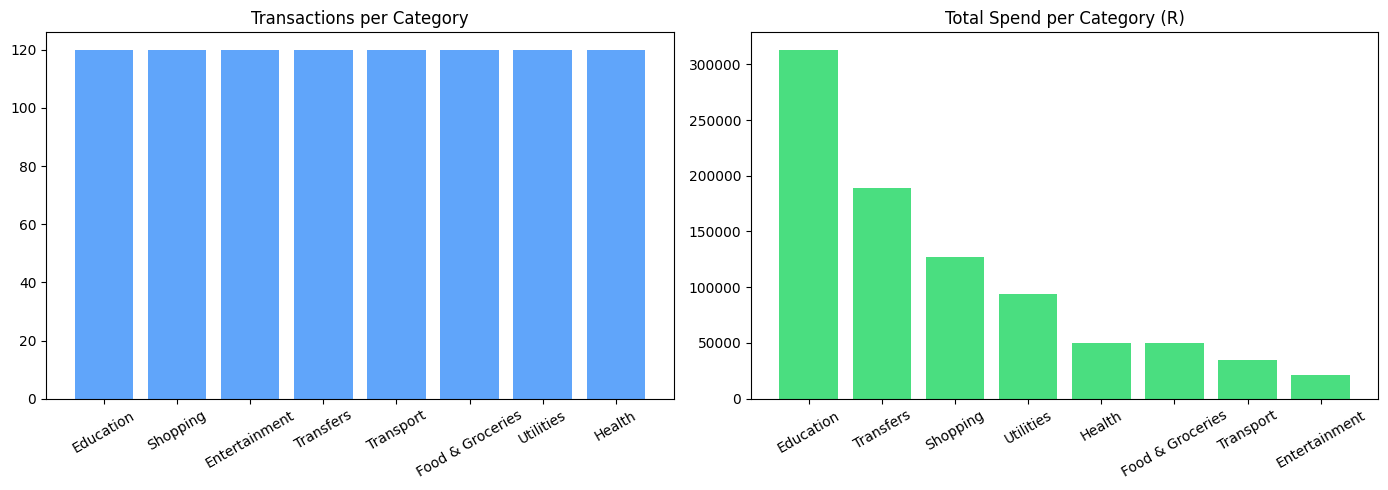


Total spend per category:
  Education            R313,010.71
  Transfers            R188,984.07
  Shopping             R127,290.34
  Utilities            R94,312.12
  Health               R50,094.27
  Food & Groceries     R49,971.58
  Transport            R34,532.84
  Entertainment        R21,113.77


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction count by category
counts = df['category'].value_counts()
axes[0].bar(counts.index, counts.values, color='#60a5fa')
axes[0].set_title('Transactions per Category')
axes[0].tick_params(axis='x', rotation=30)

# Total spend by category
totals = df.groupby('category')['amount'].sum().sort_values(ascending=False)
axes[1].bar(totals.index, totals.values, color='#4ade80')
axes[1].set_title('Total Spend per Category (R)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('\nTotal spend per category:')
for cat, total in totals.items():
    print(f'  {cat:<20} R{total:,.2f}')

## Cell 4 — Build the text classification pipeline

**How the model works:**

Transaction descriptions are raw text. We use a two-step pipeline:

1. **TF-IDF Vectorizer** — converts text descriptions into numerical vectors. TF-IDF stands for Term Frequency-Inverse Document Frequency. It measures how important a word is in a description relative to all descriptions. 'NETFLIX' appearing only in entertainment descriptions gets a high score. 'PAYMENT' appearing everywhere gets a low score.

2. **Random Forest Classifier** — takes the TF-IDF vectors and learns which word patterns correspond to which categories.

**Why this approach over a neural network?**
For short text classification with clear keywords, TF-IDF + Random Forest is fast, interpretable, and achieves very high accuracy. A neural network would be overkill and harder to explain in an interview.

In [4]:
X = df['description']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),  # use single words AND two-word phrases
        max_features=500,
        lowercase=True,
    )),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

print('Training pipeline...')
pipeline.fit(X_train, y_train)
print('Training complete.')

Training pipeline...
Training complete.


## Cell 5 — Evaluate the classifier

We expect very high accuracy here — the transaction descriptions have strong keywords that clearly indicate categories. 'NETFLIX' is always entertainment, 'ENGEN PETROL' is always transport.

The real test is whether the model generalizes to descriptions it has never seen — new merchants, slight variations in text.

In [5]:
y_pred = pipeline.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print()
print(classification_report(y_test, y_pred))

Accuracy: 1.0000 (100.0%)

                  precision    recall  f1-score   support

       Education       1.00      1.00      1.00        24
   Entertainment       1.00      1.00      1.00        24
Food & Groceries       1.00      1.00      1.00        24
          Health       1.00      1.00      1.00        24
        Shopping       1.00      1.00      1.00        24
       Transfers       1.00      1.00      1.00        24
       Transport       1.00      1.00      1.00        24
       Utilities       1.00      1.00      1.00        24

        accuracy                           1.00       192
       macro avg       1.00      1.00      1.00       192
    weighted avg       1.00      1.00      1.00       192



## Cell 6 — Test on unseen descriptions

We test the model on merchant names it has never seen during training. This proves the model is learning patterns — not just memorizing.

In [6]:
unseen_transactions = [
    'WOOLWORTHS CAFE MELROSE',
    'UBER* TRIP JHB',
    'NETFLIX.COM SUBSCRIPTION',
    'DISCHEM BABY CITY',
    'MTN DATA BUNDLE PURCHASE',
    'TAKEALOT MARKETPLACE',
    'VIRGIN ACTIVE MONTHLY',
    'IMMEDIATE PAYMENT TO FRIEND',
    'ENGEN ONE STOP HIGHWAY',
    'UNISA EXAM FEES',
]

predictions = pipeline.predict(unseen_transactions)
probabilities = pipeline.predict_proba(unseen_transactions)

print('Predictions on unseen transactions:')
print()
for desc, pred, proba in zip(unseen_transactions, predictions, probabilities):
    confidence = proba.max()
    print(f'  {desc:<40} → {pred:<20} ({confidence:.1%})')

Predictions on unseen transactions:

  WOOLWORTHS CAFE MELROSE                  → Food & Groceries     (42.5%)
  UBER* TRIP JHB                           → Transport            (100.0%)
  NETFLIX.COM SUBSCRIPTION                 → Entertainment        (52.5%)
  DISCHEM BABY CITY                        → Health               (36.0%)
  MTN DATA BUNDLE PURCHASE                 → Utilities            (71.5%)
  TAKEALOT MARKETPLACE                     → Shopping             (30.0%)
  VIRGIN ACTIVE MONTHLY                    → Health               (40.0%)
  IMMEDIATE PAYMENT TO FRIEND              → Transfers            (100.0%)
  ENGEN ONE STOP HIGHWAY                   → Food & Groceries     (27.0%)
  UNISA EXAM FEES                          → Education            (46.5%)


## Cell 7 — Spending insights engine

The classifier is one half of the system. The insights engine is the other half — it takes a full set of categorized transactions and produces meaningful analysis:

- Total spend per category
- Monthly spending trends
- Biggest single transactions
- Most frequent merchants
- Percentage breakdown

This is what the API returns alongside the categorized transactions.

In [7]:
def generate_insights(transactions_df: pd.DataFrame) -> dict:
    """
    Takes a DataFrame of categorized transactions and returns
    spending insights.

    Expected columns: date, description, amount, category
    """
    df_copy = transactions_df.copy()
    df_copy['date']  = pd.to_datetime(df_copy['date'])
    df_copy['month'] = df_copy['date'].dt.to_period('M').astype(str)

    total_spend = float(df_copy['amount'].sum())

    # Spend per category
    by_category = df_copy.groupby('category')['amount'].agg(['sum', 'count', 'mean'])
    by_category.columns = ['total', 'count', 'avg_transaction']
    by_category = by_category.sort_values('total', ascending=False)
    by_category['percentage'] = (by_category['total'] / total_spend * 100).round(1)

    # Monthly trend
    monthly = df_copy.groupby('month')['amount'].sum().reset_index()
    monthly.columns = ['month', 'total_spend']

    # Top 5 biggest transactions
    top5 = df_copy.nlargest(5, 'amount')[['date', 'description', 'amount', 'category']]
    top5['date'] = top5['date'].dt.strftime('%Y-%m-%d')

    # Most frequent merchants
    top_merchants = df_copy['description'].value_counts().head(5)

    return {
        'total_spend':      round(total_spend, 2),
        'total_transactions': len(df_copy),
        'avg_transaction':  round(float(df_copy['amount'].mean()), 2),
        'by_category':      by_category.round(2).to_dict('index'),
        'monthly_trend':    monthly.to_dict('records'),
        'top_transactions': top5.to_dict('records'),
        'top_merchants':    top_merchants.to_dict(),
    }

# Test on our generated data
insights = generate_insights(df)

print(f'Total spend:        R{insights["total_spend"]:,.2f}')
print(f'Total transactions: {insights["total_transactions"]}')
print(f'Avg transaction:    R{insights["avg_transaction"]:,.2f}')
print()
print('Spend by category:')
for cat, data in insights['by_category'].items():
    print(f'  {cat:<20} R{data["total"]:>8,.2f}  ({data["percentage"]}%)')

Total spend:        R879,309.70
Total transactions: 960
Avg transaction:    R915.95

Spend by category:
  Education            R313,010.71  (35.6%)
  Transfers            R188,984.07  (21.5%)
  Shopping             R127,290.34  (14.5%)
  Utilities            R94,312.12  (10.7%)
  Health               R50,094.27  (5.7%)
  Food & Groceries     R49,971.58  (5.7%)
  Transport            R34,532.84  (3.9%)
  Entertainment        R21,113.77  (2.4%)


## Cell 8 — Full pipeline test

Simulate what the API does when a user uploads a CSV:
1. Read the CSV
2. Classify every transaction description
3. Generate insights
4. Return everything

In [8]:
# Simulate a user uploading 20 transactions
sample_upload = pd.DataFrame({
    'date': [
        '2024-03-01', '2024-03-02', '2024-03-03', '2024-03-05',
        '2024-03-06', '2024-03-07', '2024-03-08', '2024-03-10',
        '2024-03-11', '2024-03-12', '2024-03-13', '2024-03-14',
        '2024-03-15', '2024-03-16', '2024-03-18', '2024-03-19',
        '2024-03-20', '2024-03-21', '2024-03-22', '2024-03-25',
    ],
    'description': [
        'CHECKERS FOURWAYS MALL', 'UBER TRIP SANDTON',
        'NETFLIX MONTHLY SUB', 'MTN DATA BUNDLE',
        'KFC DRIVE THROUGH', 'CLICKS PHARMACY ROSEBANK',
        'TAKEALOT ORDER', 'BP FUEL STATION N1',
        'WOOLWORTHS FOOD MALL', 'VIRGIN ACTIVE MONTHLY',
        'PICK N PAY ONLINE', 'SPOTIFY PREMIUM ZA',
        'ENGEN PETROL HIGHWAY', 'DISCHEM SUNNINGHILL',
        'STEERS BURGER', 'IMMEDIATE PAYMENT TO JOHN',
        'CITY POWER PREPAID', 'UNISA FEES 2024',
        'UBER EATS ORDER', 'MR PRICE CLOTHING',
    ],
    'amount': [
        456.50, 89.00, 169.00, 149.00,
        87.50, 234.00, 599.00, 450.00,
        312.00, 299.00, 189.00, 79.00,
        380.00, 156.00, 65.00, 500.00,
        350.00, 2800.00, 145.00, 399.00,
    ]
})

# Step 1 — Classify
sample_upload['category'] = pipeline.predict(sample_upload['description'])

# Step 2 — Generate insights
upload_insights = generate_insights(sample_upload)

print('Categorized transactions:')
print(sample_upload[['date', 'description', 'amount', 'category']].to_string(index=False))
print()
print(f'Total spend: R{upload_insights["total_spend"]:,.2f}')
print()
print('Category breakdown:')
for cat, data in upload_insights['by_category'].items():
    print(f'  {cat:<20} R{data["total"]:>8,.2f}  ({data["percentage"]}%)')

Categorized transactions:
      date               description  amount         category
2024-03-01    CHECKERS FOURWAYS MALL   456.5 Food & Groceries
2024-03-02         UBER TRIP SANDTON    89.0        Transport
2024-03-03       NETFLIX MONTHLY SUB   169.0    Entertainment
2024-03-05           MTN DATA BUNDLE   149.0        Utilities
2024-03-06         KFC DRIVE THROUGH    87.5 Food & Groceries
2024-03-07  CLICKS PHARMACY ROSEBANK   234.0           Health
2024-03-08            TAKEALOT ORDER   599.0         Shopping
2024-03-10        BP FUEL STATION N1   450.0        Transport
2024-03-11      WOOLWORTHS FOOD MALL   312.0 Food & Groceries
2024-03-12     VIRGIN ACTIVE MONTHLY   299.0           Health
2024-03-13         PICK N PAY ONLINE   189.0 Food & Groceries
2024-03-14        SPOTIFY PREMIUM ZA    79.0    Entertainment
2024-03-15      ENGEN PETROL HIGHWAY   380.0        Transport
2024-03-16       DISCHEM SUNNINGHILL   156.0           Health
2024-03-18             STEERS BURGER    65.0

## Cell 9 — Save the model

In [9]:
model_artifacts = {
    'pipeline':   pipeline,
    'categories': sorted(df['category'].unique().tolist()),
    'accuracy':   round(acc, 4),
}

with open('../spending_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print('Model saved to spending_model.pkl')
print(f'  Accuracy:   {acc:.4f} ({acc*100:.1f}%)')
print(f'  Categories: {model_artifacts["categories"]}')

Model saved to spending_model.pkl
  Accuracy:   1.0000 (100.0%)
  Categories: ['Education', 'Entertainment', 'Food & Groceries', 'Health', 'Shopping', 'Transfers', 'Transport', 'Utilities']


## Cell 10 — Sanity check

In [10]:
with open('../spending_model.pkl', 'rb') as f:
    saved = pickle.load(f)

test_descriptions = [
    'WOOLWORTHS FOOD SANDTON',
    'UBER TRIP TO AIRPORT',
    'NETFLIX SUBSCRIPTION',
    'ESKOM PREPAID TOKEN',
    'CLICKS PHARMACY',
]

predictions = saved['pipeline'].predict(test_descriptions)

print('Sanity check:')
for desc, pred in zip(test_descriptions, predictions):
    print(f'  {desc:<35} → {pred}')

print(f'\nModel accuracy: {saved["accuracy"] * 100:.1f}%')

Sanity check:
  WOOLWORTHS FOOD SANDTON             → Food & Groceries
  UBER TRIP TO AIRPORT                → Transport
  NETFLIX SUBSCRIPTION                → Entertainment
  ESKOM PREPAID TOKEN                 → Utilities
  CLICKS PHARMACY                     → Health

Model accuracy: 100.0%


---
## Done

`spending_model.pkl` is saved and ready for the FastAPI server.

**Next step:** Build `api.py` — accepts a CSV upload, classifies every transaction, returns categorized data and spending insights.